# Day 7 - Pandas Advanced + Visualization + SQL Essentials

In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

## Task 1 - Load and Audit

In [85]:
customers = pd.read_csv("customers.csv")
products = pd.read_csv("products.csv")
orders = pd.read_csv("orders.csv")

In [86]:
customers.shape

(10, 4)

In [87]:
products.shape

(8, 4)

In [88]:
orders.shape

(16, 6)

In [89]:
customers.head()

,customer_id,name,segment,region
0,C001,Harsh Patidar,Consumer,North
1,C002,Dheeraj Saini,corporate,South
2,C003,Gaurav Dwivedi,Consumer,East
3,C004,Gopal Sharma,home office,West
4,C005,Govind Patel,consumer,North


In [90]:
products.head()

,product_id,product_name,category,price
0,P001,Laptop,Electronics,45000
1,P002,Office Chair,Furniture,8500
2,P003,Notebook Pack,Office Supplies,250
3,P004,Smartphone,Electronics,$18000
4,P005,Desk,Furniture,NaN


In [91]:
orders.head()

,order_id,customer_id,product_id,order_date,quantity,discount
0,O001,C001,P001,2024-01-15,2,0.10
1,O002,C002,P003,2024-01-22,10,0.00
2,O003,C003,P002,2024-02-10,1,0.05
3,O004,C004,P004,2024-02-28,3,0.15
4,O005,C005,P006,2024-03-05,20,0.00


In [92]:
customers.dtypes

customer_id    object
name           object
segment        object
region         object
dtype: object

In [93]:
products.dtypes

product_id      object
product_name    object
category        object
price           object
dtype: object

In [94]:
orders.dtypes

order_id        object
customer_id     object
product_id      object
order_date      object
quantity         int64
discount       float64
dtype: object

In [95]:
customers.isnull().sum()

customer_id    0
name           0
segment        0
region         0
dtype: int64

In [96]:
products.isnull().sum()

product_id      0
product_name    0
category        0
price           1
dtype: int64

In [97]:
orders.isnull().sum()

order_id       0
customer_id    0
product_id     0
order_date     0
quantity       0
discount       0
dtype: int64

In [98]:
customers.duplicated().sum()

np.int64(0)

In [99]:
products.duplicated().sum()

np.int64(0)

In [100]:
orders.duplicated().sum()

np.int64(1)

In [101]:
customers.nunique()

customer_id    10
name           10
segment         7
region          8
dtype: int64

In [102]:
products.nunique()

product_id      8
product_name    8
category        3
price           7
dtype: int64

In [103]:
orders.nunique()

order_id       15
customer_id    10
product_id      8
order_date     15
quantity        7
discount        5
dtype: int64

### Observation: Customers has mixed casing in region and segment, products has a missing price for desk and a dollar sign, and orders has one duplicate row with dates as strings.

## Task 2 - Clean the Data

In [104]:
customers["segment"] = customers["segment"].str.strip().str.title()
customers["region"] = customers["region"].str.strip().str.title()
customers

,customer_id,name,segment,region
0,C001,Harsh Patidar,Consumer,North
1,C002,Dheeraj Saini,Corporate,South
2,C003,Gaurav Dwivedi,Consumer,East
3,C004,Gopal Sharma,Home Office,West
4,C005,Govind Patel,Consumer,North
5,C006,Dixit,Corporate,South
6,C007,Amit Sharma,Consumer,East
7,C008,Priya Verma,Home Office,West
8,C009,Rahul Jain,Consumer,North
9,C010,Sneha Patel,Corporate,South


In [105]:
products["price"] = products["price"].astype(str).str.replace("$", "", regex=False)
products["price"] = pd.to_numeric(products["price"], errors="coerce")

furniture_avg = products[products["category"] == "Furniture"]["price"].mean()
products["price"] = products["price"].fillna(furniture_avg)
products

,product_id,product_name,category,price
0,P001,Laptop,Electronics,45000.0
1,P002,Office Chair,Furniture,8500.0
2,P003,Notebook Pack,Office Supplies,250.0
3,P004,Smartphone,Electronics,18000.0
4,P005,Desk,Furniture,10250.0
5,P006,Pen Set,Office Supplies,150.0
6,P007,Tablet,Electronics,22000.0
7,P008,Bookshelf,Furniture,12000.0


In [106]:
orders["order_date"] = pd.to_datetime(orders["order_date"])
orders = orders.drop_duplicates()
orders.shape

(15, 6)

### Observation: Stripped and capitalized customer fields, removed dollar sign and filled missing price with furniture average, converted date type, and dropped the duplicate order.

## Task 3 - Groupby Analysis

In [107]:
sales = orders.merge(customers, on="customer_id").merge(products, on="product_id")
sales["revenue"] = sales["quantity"] * sales["price"] * (1 - sales["discount"])
sales.head()

,order_id,customer_id,product_id,order_date,quantity,discount,name,segment,region,product_name,category,price,revenue
0,O001,C001,P001,2024-01-15,2,0.10,Harsh Patidar,Consumer,North,Laptop,Electronics,45000.0,81000.0
1,O002,C002,P003,2024-01-22,10,0.00,Dheeraj Saini,Corporate,South,Notebook Pack,Office Supplies,250.0,2500.0
2,O003,C003,P002,2024-02-10,1,0.05,Gaurav Dwivedi,Consumer,East,Office Chair,Furniture,8500.0,8075.0
3,O004,C004,P004,2024-02-28,3,0.15,Gopal Sharma,Home Office,West,Smartphone,Electronics,18000.0,45900.0
4,O005,C005,P006,2024-03-05,20,0.00,Govind Patel,Consumer,North,Pen Set,Office Supplies,150.0,3000.0


In [108]:
sales.groupby("region")[["revenue", "quantity"]].sum()

,revenue,quantity
region,,
East,77637.5,30
North,163200.0,27
South,23475.0,26
West,66400.0,5


In [109]:
sales.groupby("category")[["revenue", "quantity"]].sum()

,revenue,quantity
category,,
Electronics,242600.0,10
Furniture,75675.0,8
Office Supplies,12437.5,70


In [110]:
sales.groupby(["region", "category"])[["revenue", "quantity"]].sum()

revenue  quantity
region category                           
East   Electronics       40500.0         1
       Furniture         33575.0         4
       Office Supplies    3562.5        25
North  Electronics      138600.0         5
       Furniture         21600.0         2
       Office Supplies    3000.0        20
South  Electronics       17600.0         1
       Office Supplies    5875.0        25
West   Electronics       45900.0         3
       Furniture         20500.0         2

In [111]:
sales.groupby("segment").agg(
    total_revenue=("revenue", "sum"),
    avg_revenue=("revenue", "mean"),
    total_orders=("order_id", "count")
)

,total_revenue,avg_revenue,total_orders
segment,,,
Consumer,240837.5,24083.75,10
Corporate,23475.0,7825.00,3
Home Office,66400.0,33200.00,2


### Observation: North region and electronics category drive the most sales, and the consumer segment is placing the most orders.

## Task 4 - Merge and Key Metrics

In [112]:
sales["revenue"].sum()

np.float64(330712.5)

In [113]:
sales["revenue"].mean() # average order value

np.float64(22047.5)

In [114]:
sales.groupby("product_name")["revenue"].sum().sort_values(ascending=False)

product_name
Laptop           121500.0
Smartphone        63900.0
Tablet            57200.0
Office Chair      33575.0
Bookshelf         21600.0
Desk              20500.0
Pen Set            6562.5
Notebook Pack      5875.0
Name: revenue, dtype: float64

In [115]:
sales[["order_id", "name", "product_name", "category", "region", "quantity", "price", "discount", "revenue"]]

,order_id,name,product_name,category,region,quantity,price,discount,revenue
0,O001,Harsh Patidar,Laptop,Electronics,North,2,45000.0,0.10,81000.0
1,O002,Dheeraj Saini,Notebook Pack,Office Supplies,South,10,250.0,0.00,2500.0
2,O003,Gaurav Dwivedi,Office Chair,Furniture,East,1,8500.0,0.05,8075.0
3,O004,Gopal Sharma,Smartphone,Electronics,West,3,18000.0,0.15,45900.0
4,O005,Govind Patel,Pen Set,Office Supplies,North,20,150.0,0.00,3000.0
5,O006,Dixit,Tablet,Electronics,South,1,22000.0,0.20,17600.0
6,O007,Amit Sharma,Laptop,Electronics,East,1,45000.0,0.10,40500.0
7,O008,Priya Verma,Desk,Furniture,West,2,10250.0,0.00,20500.0
8,O009,Rahul Jain,Bookshelf,Furniture,North,1,12000.0,0.05,11400.0
9,O010,Sneha Patel,Notebook Pack,Office Supplies,South,15,250.0,0.10,3375.0


## Task 5 - Pivot Tables

In [116]:
pivot1 = sales.pivot_table(values="revenue", index="region", columns="category", aggfunc="sum", fill_value=0)
pivot1

category,Electronics,Furniture,Office Supplies
region,,,
East,40500.0,33575.0,3562.5
North,138600.0,21600.0,3000.0
South,17600.0,0.0,5875.0
West,45900.0,20500.0,0.0


In [117]:
sales["month"] = sales["order_date"].dt.month_name()
pivot2 = sales.pivot_table(values="revenue", index="segment", columns="month", aggfunc="mean", fill_value=0)
pivot2

month,April,August,February,January,July,June,March,May
segment,,,,,,,,
Consumer,40500.0,10200.0,8075.0,81000.0,32550.0,10781.25,3000.0,11400.0
Corporate,0.0,0.0,0.0,2500.0,0.0,0.00,17600.0,3375.0
Home Office,20500.0,0.0,45900.0,0.0,0.0,0.00,0.0,0.0


## Task 6 - Visualizations

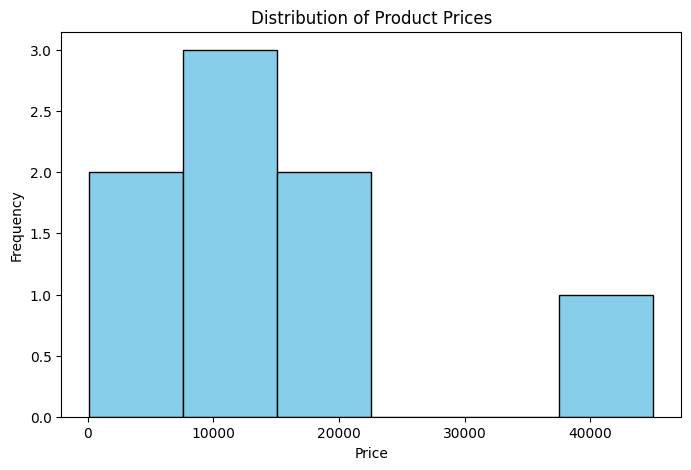

In [118]:
plt.figure(figsize=(8, 5))
plt.hist(products["price"], bins=6, color="skyblue", edgecolor="black")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.title("Distribution of Product Prices")
plt.show()

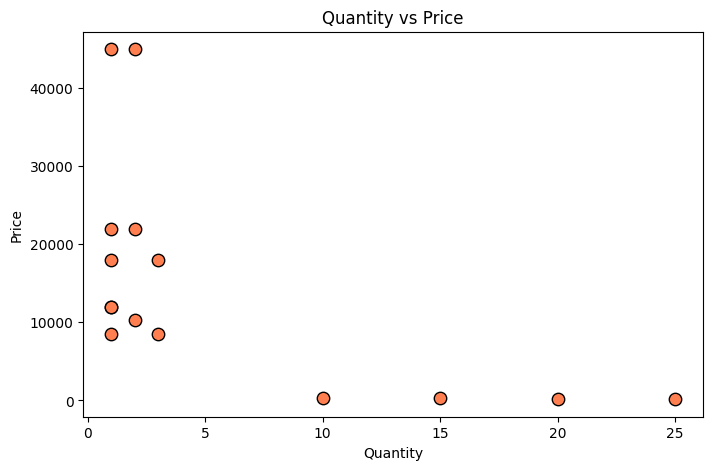

In [119]:
plt.figure(figsize=(8, 5))
plt.scatter(sales["quantity"], sales["price"], color="coral", edgecolor="black", s=80)
plt.xlabel("Quantity")
plt.ylabel("Price")
plt.title("Quantity vs Price")
plt.show()

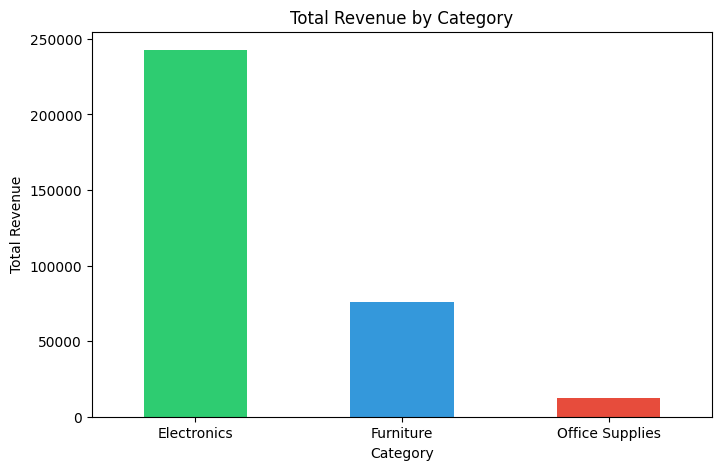

In [120]:
cat_revenue = sales.groupby("category")["revenue"].sum()

plt.figure(figsize=(8, 5))
cat_revenue.plot(kind="bar", color=["#2ecc71", "#3498db", "#e74c3c"])
plt.xlabel("Category")
plt.ylabel("Total Revenue")
plt.title("Total Revenue by Category")
plt.xticks(rotation=0)
plt.show()

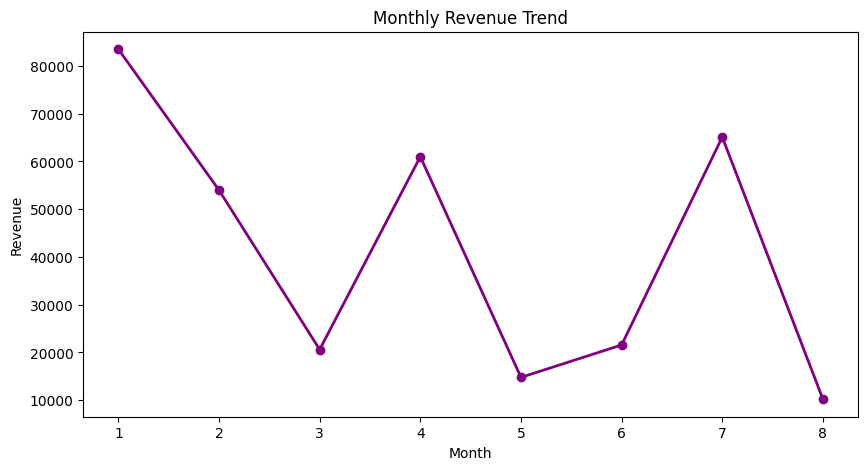

In [121]:
sales["month_num"] = sales["order_date"].dt.month
monthly = sales.groupby("month_num")["revenue"].sum()

plt.figure(figsize=(10, 5))
plt.plot(monthly.index, monthly.values, marker="o", color="purple", linewidth=2)
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.title("Monthly Revenue Trend")
plt.xticks(monthly.index)
plt.show()

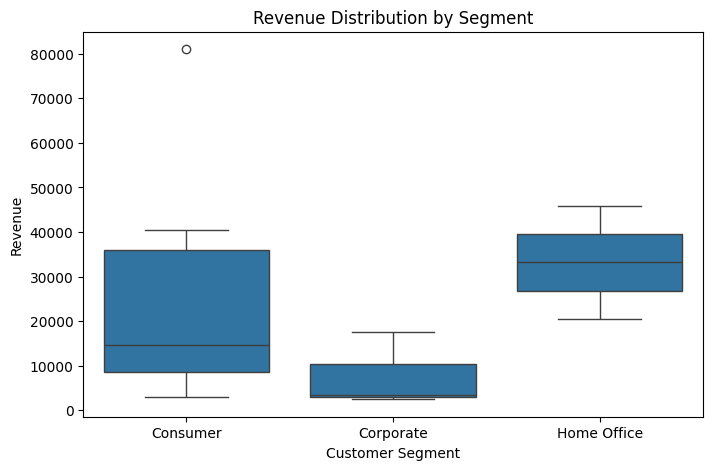

In [123]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="segment", y="revenue", data=sales, )
plt.xlabel("Customer Segment")
plt.ylabel("Revenue")
plt.title("Revenue Distribution by Segment")
plt.show()

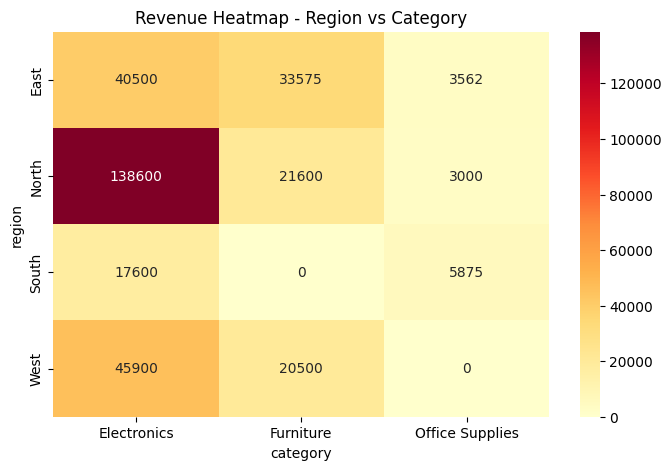

In [124]:
plt.figure(figsize=(8, 5))
sns.heatmap(pivot1, annot=True, fmt=".0f", cmap="YlOrRd")
plt.title("Revenue Heatmap - Region vs Category")
plt.show()

### Observation: Electronics makes the most revenue because of high prices, North region is our best market, and sales peaked in January and summer months.

## Task 8 - SQLite Database and 15 SQL Queries

In [125]:
conn = sqlite3.connect(":memory:")

customers.to_sql("customers", conn, index=False)
products.to_sql("products", conn, index=False)
orders.to_sql("orders", conn, index=False)

15

### Basic Queries

In [126]:
pd.read_sql("SELECT * FROM customers", conn)

,customer_id,name,segment,region
0,C001,Harsh Patidar,Consumer,North
1,C002,Dheeraj Saini,Corporate,South
2,C003,Gaurav Dwivedi,Consumer,East
3,C004,Gopal Sharma,Home Office,West
4,C005,Govind Patel,Consumer,North
5,C006,Dixit,Corporate,South
6,C007,Amit Sharma,Consumer,East
7,C008,Priya Verma,Home Office,West
8,C009,Rahul Jain,Consumer,North
9,C010,Sneha Patel,Corporate,South


In [127]:
pd.read_sql("SELECT * FROM products WHERE category = 'Electronics'", conn)

,product_id,product_name,category,price
0,P001,Laptop,Electronics,45000.0
1,P004,Smartphone,Electronics,18000.0
2,P007,Tablet,Electronics,22000.0


In [128]:
pd.read_sql("SELECT * FROM orders ORDER BY order_date DESC LIMIT 5", conn)

,order_id,customer_id,product_id,order_date,quantity,discount
0,O015,C009,P008,2024-08-15 00:00:00,1,0.15
1,O014,C007,P002,2024-07-30 00:00:00,3,0.00
2,O013,C005,P007,2024-07-12 00:00:00,2,0.10
3,O012,C003,P006,2024-06-25 00:00:00,25,0.05
4,O011,C001,P004,2024-06-10 00:00:00,1,0.00


In [129]:
pd.read_sql("SELECT COUNT(*) AS total_orders FROM orders", conn)

,total_orders
0,15


In [130]:
pd.read_sql("SELECT AVG(price) AS avg_price FROM products", conn)

,avg_price
0,14518.75


### Intermediate Queries

In [131]:
pd.read_sql("SELECT category, SUM(price) AS total_price FROM products GROUP BY category", conn)

,category,total_price
0,Electronics,85000.0
1,Furniture,30750.0
2,Office Supplies,400.0


In [132]:
pd.read_sql("SELECT * FROM orders WHERE discount > 0 ORDER BY discount DESC", conn)

,order_id,customer_id,product_id,order_date,quantity,discount
0,O006,C006,P007,2024-03-18 00:00:00,1,0.20
1,O004,C004,P004,2024-02-28 00:00:00,3,0.15
2,O015,C009,P008,2024-08-15 00:00:00,1,0.15
3,O001,C001,P001,2024-01-15 00:00:00,2,0.10
4,O007,C007,P001,2024-04-02 00:00:00,1,0.10
5,O010,C010,P003,2024-05-20 00:00:00,15,0.10
6,O013,C005,P007,2024-07-12 00:00:00,2,0.10
7,O003,C003,P002,2024-02-10 00:00:00,1,0.05
8,O009,C009,P008,2024-05-01 00:00:00,1,0.05
9,O012,C003,P006,2024-06-25 00:00:00,25,0.05


In [133]:
pd.read_sql("""SELECT o.order_id, c.name, c.region, o.quantity 
               FROM orders o 
               JOIN customers c ON o.customer_id = c.customer_id""", conn)

,order_id,name,region,quantity
0,O001,Harsh Patidar,North,2
1,O002,Dheeraj Saini,South,10
2,O003,Gaurav Dwivedi,East,1
3,O004,Gopal Sharma,West,3
4,O005,Govind Patel,North,20
5,O006,Dixit,South,1
6,O007,Amit Sharma,East,1
7,O008,Priya Verma,West,2
8,O009,Rahul Jain,North,1
9,O010,Sneha Patel,South,15


In [134]:
pd.read_sql("""SELECT c.region, COUNT(o.order_id) AS order_count 
               FROM orders o 
               JOIN customers c ON o.customer_id = c.customer_id 
               GROUP BY c.region""", conn)

,region,order_count
0,East,4
1,North,6
2,South,3
3,West,2


In [135]:
pd.read_sql("""SELECT c.region, SUM(o.quantity) AS total_qty 
               FROM orders o 
               JOIN customers c ON o.customer_id = c.customer_id 
               GROUP BY c.region 
               HAVING total_qty > 5""", conn)

,region,total_qty
0,East,30
1,North,27
2,South,26


### Advanced Queries

In [136]:
pd.read_sql("""SELECT o.order_id, c.name, p.product_name, o.quantity, p.price 
               FROM orders o 
               JOIN customers c ON o.customer_id = c.customer_id 
               JOIN products p ON o.product_id = p.product_id""", conn)

,order_id,name,product_name,quantity,price
0,O001,Harsh Patidar,Laptop,2,45000.0
1,O002,Dheeraj Saini,Notebook Pack,10,250.0
2,O003,Gaurav Dwivedi,Office Chair,1,8500.0
3,O004,Gopal Sharma,Smartphone,3,18000.0
4,O005,Govind Patel,Pen Set,20,150.0
5,O006,Dixit,Tablet,1,22000.0
6,O007,Amit Sharma,Laptop,1,45000.0
7,O008,Priya Verma,Desk,2,10250.0
8,O009,Rahul Jain,Bookshelf,1,12000.0
9,O010,Sneha Patel,Notebook Pack,15,250.0


In [137]:
pd.read_sql("""SELECT name, segment FROM customers 
               WHERE customer_id IN 
               (SELECT customer_id FROM orders WHERE quantity > 5)""", conn)

,name,segment
0,Dheeraj Saini,Corporate
1,Gaurav Dwivedi,Consumer
2,Govind Patel,Consumer
3,Sneha Patel,Corporate


In [138]:
pd.read_sql("""SELECT p.product_name, SUM(o.quantity) AS total_sold 
               FROM orders o 
               JOIN products p ON o.product_id = p.product_id 
               GROUP BY p.product_name 
               ORDER BY total_sold DESC""", conn)

,product_name,total_sold
0,Pen Set,45
1,Notebook Pack,25
2,Smartphone,4
3,Office Chair,4
4,Tablet,3
5,Laptop,3
6,Desk,2
7,Bookshelf,2


In [139]:
pd.read_sql("""SELECT region, avg_qty FROM 
               (SELECT c.region, AVG(o.quantity) AS avg_qty 
                FROM orders o 
                JOIN customers c ON o.customer_id = c.customer_id 
                GROUP BY c.region) 
               WHERE avg_qty > 3""", conn)

,region,avg_qty
0,East,7.500000
1,North,4.500000
2,South,8.666667


In [140]:
pd.read_sql("""SELECT c.segment, COUNT(o.order_id) AS orders, 
               SUM(o.quantity * p.price * (1 - o.discount)) AS revenue 
               FROM orders o 
               JOIN customers c ON o.customer_id = c.customer_id 
               JOIN products p ON o.product_id = p.product_id 
               GROUP BY c.segment 
               ORDER BY revenue DESC""", conn)

,segment,orders,revenue
0,Consumer,10,240837.5
1,Home Office,2,66400.0
2,Corporate,3,23475.0


## Task 9 - Pandas vs SQL Comparison

Replicating the same analysis: total revenue by region

In [141]:
# pandas way
sales.groupby("region")["revenue"].sum()

region
East      77637.5
North    163200.0
South     23475.0
West      66400.0
Name: revenue, dtype: float64

In [142]:
# sql way
pd.read_sql("""SELECT c.region, SUM(o.quantity * p.price * (1 - o.discount)) AS revenue 
               FROM orders o 
               JOIN customers c ON o.customer_id = c.customer_id 
               JOIN products p ON o.product_id = p.product_id 
               GROUP BY c.region 
               ORDER BY revenue DESC""", conn)

,region,revenue
0,North,163200.0
1,East,77637.5
2,West,66400.0
3,South,23475.0


### Observation: Pandas is shorter since we already have the merged dataframe, while SQL requires writing joins and calculation inside the query.

In [143]:
conn.close()